In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# NormModel 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.0075 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.NormModel import NormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 8
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [6]:
model = NormModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=150,
    lr=0.002,
    print_on=10,
    save_dir="../models/norm_img64_c4_lr_0.002_os/",
    save_checkpoints=10,
    checkpoint_name="norm_64x64_train_0_"
)

Epoch 10/150 | Train Loss: 0.7761 | Validation Loss: 0.7642
Epoch 20/150 | Train Loss: 0.7267 | Validation Loss: 0.7460
Epoch 30/150 | Train Loss: 0.6838 | Validation Loss: 0.6933
Epoch 40/150 | Train Loss: 0.6439 | Validation Loss: 0.6662
Epoch 50/150 | Train Loss: 0.6083 | Validation Loss: 0.6912
Epoch 60/150 | Train Loss: 0.5920 | Validation Loss: 0.7118
Epoch 70/150 | Train Loss: 0.5597 | Validation Loss: 0.6371
Epoch 80/150 | Train Loss: 0.5286 | Validation Loss: 0.6383
Epoch 90/150 | Train Loss: 0.5163 | Validation Loss: 0.6427
Epoch 100/150 | Train Loss: 0.4895 | Validation Loss: 0.6524
Epoch 110/150 | Train Loss: 0.4775 | Validation Loss: 0.6256
Epoch 120/150 | Train Loss: 0.4641 | Validation Loss: 0.6376
Epoch 130/150 | Train Loss: 0.4440 | Validation Loss: 0.6277
Epoch 140/150 | Train Loss: 0.4397 | Validation Loss: 0.6881
Epoch 150/150 | Train Loss: 0.4289 | Validation Loss: 0.6351


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [13]:
metrics.iloc[20:60]

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
20,21,0.724058,0.654645,0.554057,0.470621,0.468592,0.768269,0.621347,0.686139,0.471361,0.452274
21,22,0.715446,0.665847,0.616564,0.481556,0.482499,0.719659,0.647607,0.547499,0.476730,0.484215
22,23,0.713409,0.665027,0.586319,0.482238,0.483616,0.827740,0.568403,0.462991,0.427242,0.374447
23,24,0.705023,0.667031,0.606760,0.483901,0.485353,0.713066,0.653537,0.449219,0.449104,0.434399
24,25,0.702323,0.672404,0.620157,0.489000,0.491657,0.722919,0.645489,0.611578,0.488000,0.490532
25,26,0.695885,0.680783,0.597642,0.495464,0.497971,0.731129,0.641254,0.618200,0.487596,0.479224
26,27,0.694718,0.678597,0.613705,0.496991,0.501694,0.727708,0.650148,0.602826,0.491601,0.486013
27,28,0.692614,0.685883,0.638054,0.500672,0.504593,0.751082,0.632359,0.685758,0.485812,0.470777
28,29,0.683104,0.679781,0.620397,0.498499,0.503081,0.697883,0.655654,0.501926,0.465084,0.453059
29,30,0.683753,0.686794,0.641074,0.503488,0.509154,0.693345,0.664972,0.589955,0.476568,0.471465


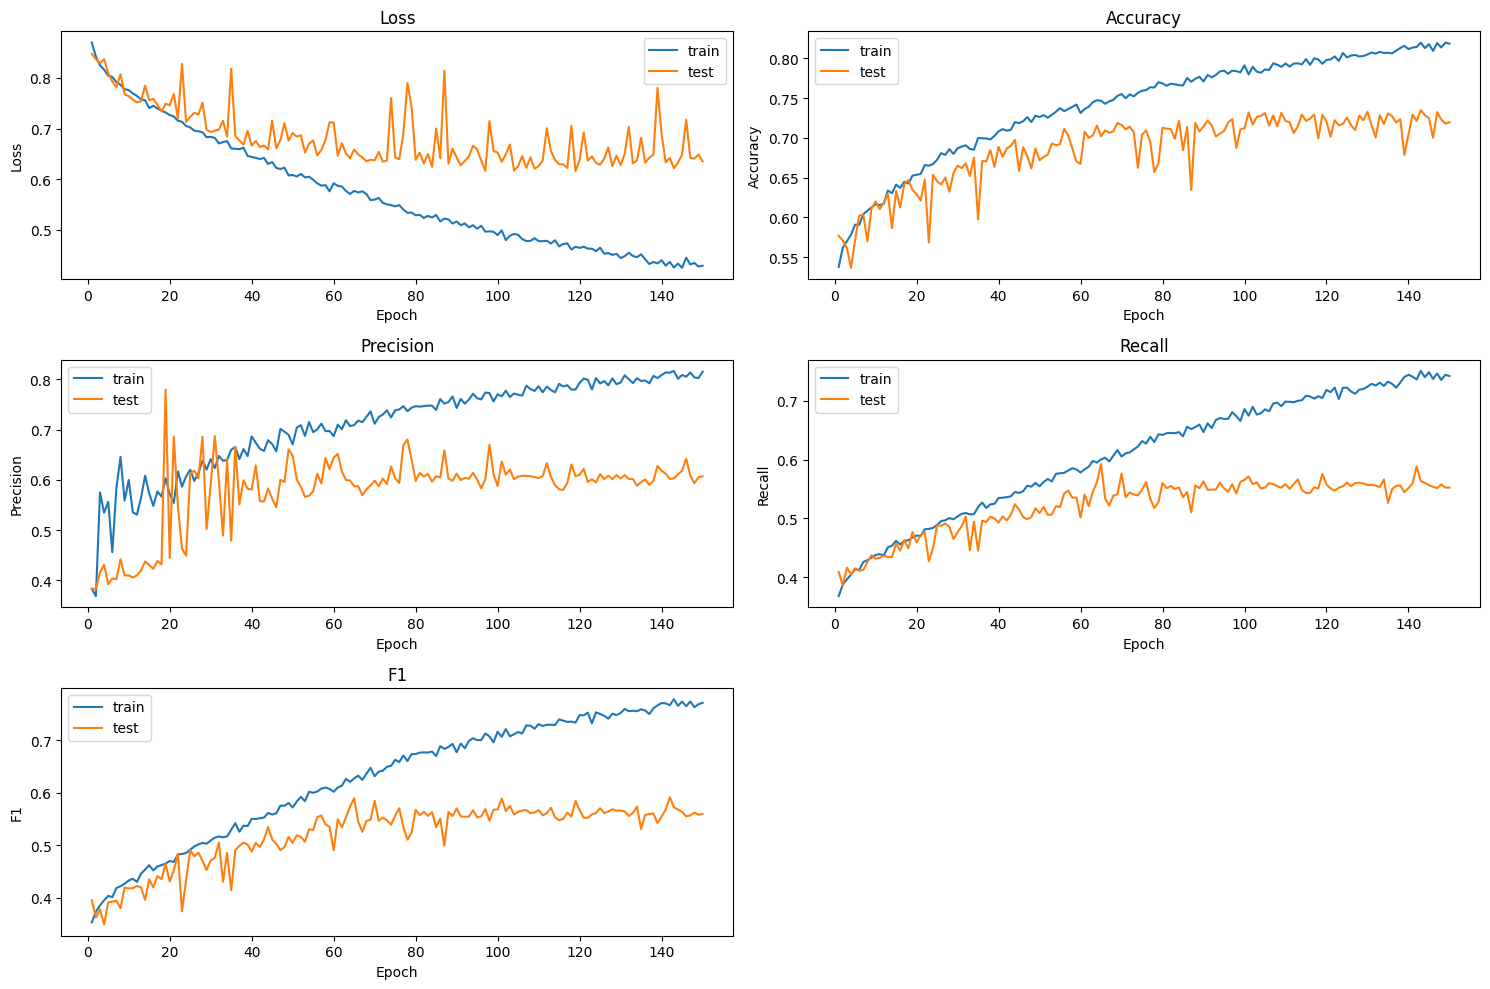

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"test_{metric}",
        ax=ax,
        label="test"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()